# Credit Card Fraud Detection
## Phase 7: Final Evaluation

In this final phase, we compare the Autoencoder anomaly detection model against the supervised XGBoost model on the untouched test set. We will evaluate performance using PR-AUC, Precision, Recall, and F1, followed by a deeper error analysis of false positives and false negatives.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader, TensorDataset
import sys
import yaml
import joblib
from sklearn.metrics import precision_recall_curve, roc_auc_score, auc, confusion_matrix, precision_score, recall_score, f1_score

# Add src to path
sys.path.append('../')
from src.preprocessing import split_data_anomaly_detection, preprocess_features, load_config
from src.autoencoder import Autoencoder, get_device, compute_reconstruction_error
from src.evaluation import plot_confusion_matrix

# Load config
config = load_config('../configs/config.yaml')


### 1. Load Data and Models
We evaluate specifically on the Test set now.

In [2]:
df = pd.read_csv('../' + config['data']['subset_path'])

train_df, val_df, test_df = split_data_anomaly_detection(
    df, 
    val_size=config['data']['val_size'], 
    test_size=config['data']['test_size'], 
    random_state=config['random_seed']
)

(X_train, y_train), (X_val, y_val), (X_test, y_test), (scaler_time, scaler_amount) = preprocess_features(train_df, val_df, test_df)

device = get_device()
input_dim = X_train.shape[1]

# Load AE Model
ae_model = Autoencoder(input_dim=input_dim, latent_dim=config['model']['latent_dim'], dropout=config['model']['dropout'])
ae_model.load_state_dict(torch.load('../models/autoencoder_baseline.pth', map_location=device, weights_only=True))
ae_model.to(device)
ae_model.eval()

# Load AE Threshold
ae_threshold = config.get('threshold', {}).get('value', 20.0)

# Load XGB Model
xgb_model = joblib.load('../models/xgboost_baseline.pkl')


Using CPU


### 2. Predict on Test Set

In [3]:
# 1. AE Predictions
test_dataset = TensorDataset(torch.FloatTensor(X_test))
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
ae_scores = compute_reconstruction_error(ae_model, test_loader, device)
ae_preds = (ae_scores >= ae_threshold).astype(int)

# 2. XGB Predictions
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)


### 3. Metric Comparison
We compare both models on PR-AUC, ROC-AUC, Precision, Recall, and F1-score.

In [4]:
def get_metrics(y_true, probs, preds):
    precisions, recalls, _ = precision_recall_curve(y_true, probs)
    return {
        'PR-AUC': auc(recalls, precisions),
        'ROC-AUC': roc_auc_score(y_true, probs),
        'Precision': precision_score(y_true, preds, zero_division=0),
        'Recall': recall_score(y_true, preds, zero_division=0),
        'F1-Score': f1_score(y_true, preds, zero_division=0)
    }

ae_metrics = get_metrics(y_test, ae_scores, ae_preds)
xgb_metrics = get_metrics(y_test, xgb_probs, xgb_preds)

metrics_df = pd.DataFrame([ae_metrics, xgb_metrics], index=['Autoencoder', 'XGBoost'])
display(metrics_df)


,PR-AUC,ROC-AUC,Precision,Recall,F1-Score
Autoencoder,0.767663,0.958519,0.699275,0.784553,0.739464
XGBoost,0.971975,0.993316,0.939759,0.951220,0.945455


### 4. Visual Comparison
Comparing Precision-Recall curves and Confusion Matrices.

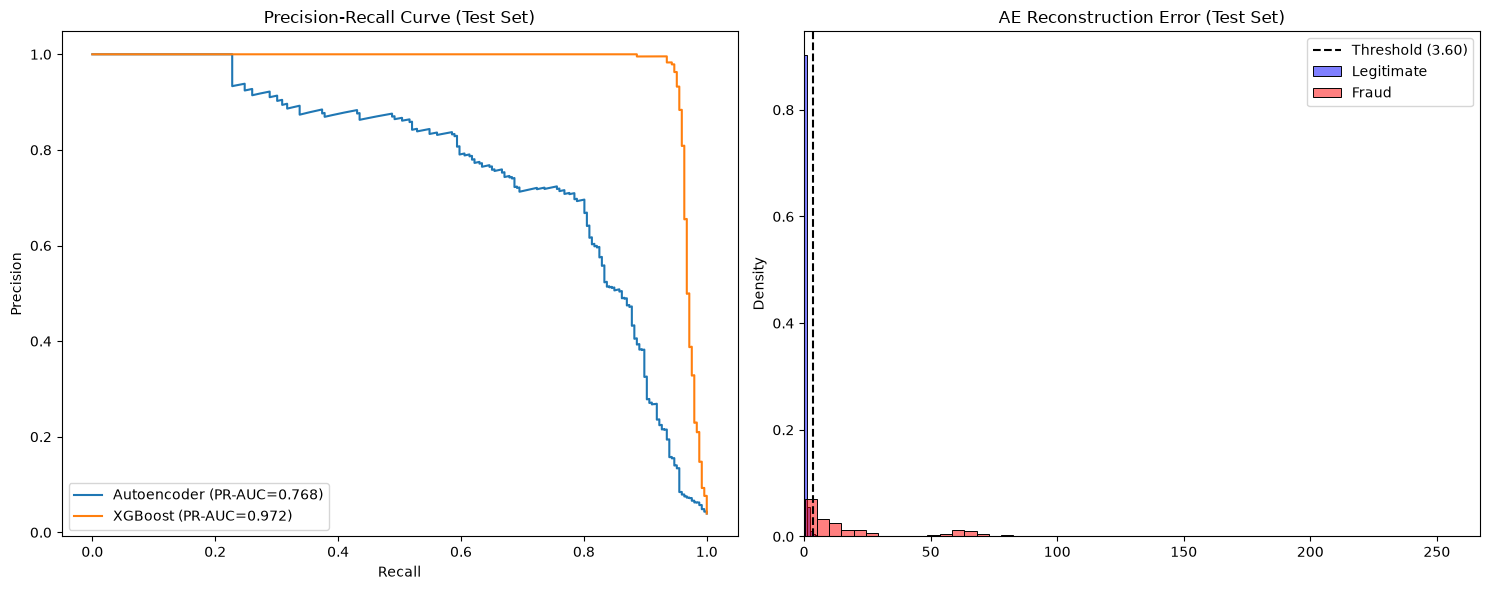

Confusion Matrices:


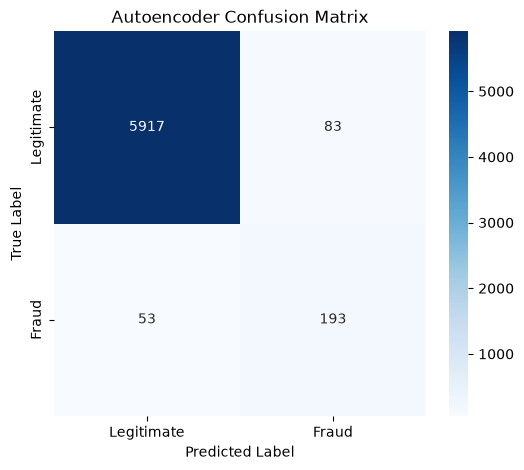

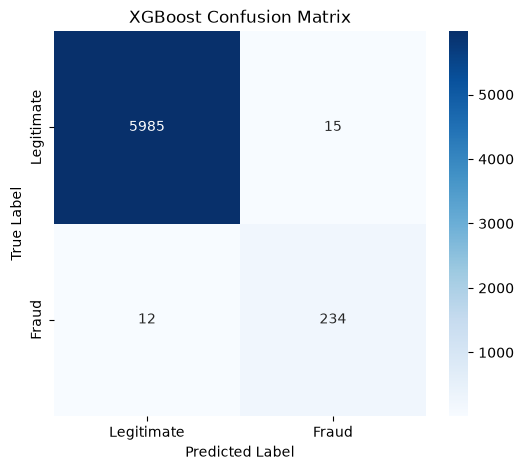

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PR Curve
ae_p, ae_r, _ = precision_recall_curve(y_test, ae_scores)
xgb_p, xgb_r, _ = precision_recall_curve(y_test, xgb_probs)

axes[0].plot(ae_r, ae_p, label=f"Autoencoder (PR-AUC={ae_metrics['PR-AUC']:.3f})")
axes[0].plot(xgb_r, xgb_p, label=f"XGBoost (PR-AUC={xgb_metrics['PR-AUC']:.3f})")
axes[0].set_title('Precision-Recall Curve (Test Set)')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].legend()

# Reconstruction Error Distribution (Autoencoder)
normal_idx = (y_test == 0)
fraud_idx = (y_test == 1)

sns.histplot(ae_scores[normal_idx], bins=50, color='blue', alpha=0.5, label='Legitimate', stat='density', ax=axes[1])
sns.histplot(ae_scores[fraud_idx], bins=50, color='red', alpha=0.5, label='Fraud', stat='density', ax=axes[1])
axes[1].axvline(ae_threshold, color='black', linestyle='--', label=f'Threshold ({ae_threshold:.2f})')
axes[1].set_title('AE Reconstruction Error (Test Set)')
axes[1].set_xlim(0, max(ae_scores[normal_idx].max(), ae_scores[fraud_idx].max()) * 1.1)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Confusion Matrices:")
plot_confusion_matrix(y_test, ae_preds, title='Autoencoder Confusion Matrix')
plot_confusion_matrix(y_test, xgb_preds, title='XGBoost Confusion Matrix')


### 5. Error Analysis
Let's analyze the False Positives and False Negatives of the Autoencoder. Why did it fail on these specific cases?

In [6]:
# Identify specific cases
fp_idx = np.where((ae_preds == 1) & (y_test == 0))[0]
fn_idx = np.where((ae_preds == 0) & (y_test == 1))[0]

print(f"Total False Positives (Legitimate flagged as Fraud): {len(fp_idx)}")
print(f"Total False Negatives (Fraud flagged as Legitimate): {len(fn_idx)}")

if len(fp_idx) > 0:
    print("\nSample False Positives (Reconstruction Scores):")
    print(ae_scores[fp_idx[:5]])
    
if len(fn_idx) > 0:
    print("\nSample False Negatives (Reconstruction Scores):")
    print(ae_scores[fn_idx[:5]])

print("\nAnalysis:")
print("False Positives occur when legitimate transactions exhibit feature combinations that the Autoencoder has rarely seen during training, causing high reconstruction error.")
print("False Negatives occur when fraudulent transactions successfully mimic normal transaction behavior, resulting in a low reconstruction error that falls below our threshold.")


Total False Positives (Legitimate flagged as Fraud): 83
Total False Negatives (Fraud flagged as Legitimate): 53

Sample False Positives (Reconstruction Scores):
[ 6.096509   9.084138   4.2072234 14.213688   4.447623 ]

Sample False Negatives (Reconstruction Scores):
[2.595897  1.1925896 2.7574115 2.1555796 1.0448207]

Analysis:
False Positives occur when legitimate transactions exhibit feature combinations that the Autoencoder has rarely seen during training, causing high reconstruction error.
False Negatives occur when fraudulent transactions successfully mimic normal transaction behavior, resulting in a low reconstruction error that falls below our threshold.
